# Data Understanding - Sirio-Libanes ICU (Clustering)

This dataset has many features (231 columns) and a high missing rate. We will focus on assessing the missingness and analyzing the `0-2` window.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 1. Load Data

In [2]:
DATA_FILE = 'Kaggle_Sirio_Libanes_ICU_Prediction.xlsx'
df = pd.read_excel(DATA_FILE, engine='openpyxl')
print(f'Dimensions: {df.shape}')
display(df.head())

Dimensions: (1925, 231)


,PATIENT_VISIT_IDENTIFIER,AGE_ABOVE65,AGE_PERCENTIL,GENDER,DISEASE GROUPING 1,DISEASE GROUPING 2,DISEASE GROUPING 3,DISEASE GROUPING 4,DISEASE GROUPING 5,DISEASE GROUPING 6,...,TEMPERATURE_DIFF,OXYGEN_SATURATION_DIFF,BLOODPRESSURE_DIASTOLIC_DIFF_REL,BLOODPRESSURE_SISTOLIC_DIFF_REL,HEART_RATE_DIFF_REL,RESPIRATORY_RATE_DIFF_REL,TEMPERATURE_DIFF_REL,OXYGEN_SATURATION_DIFF_REL,WINDOW,ICU
0,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0-2,0
1,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,2-4,0
2,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4-6,0
3,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,...,-1.000000,-1.000000,NaN,NaN,NaN,NaN,-1.000000,-1.000000,6-12,0
4,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,...,-0.238095,-0.818182,-0.389967,0.407558,-0.230462,0.096774,-0.242282,-0.814433,ABOVE_12,1


## 2. Patients & Windows

Unique Patient Identifiers: 385
Average rows per patient: 5.00


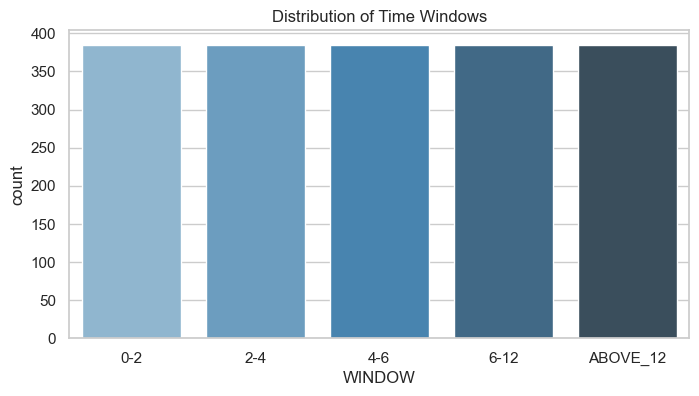

In [3]:
print(f"Unique Patient Identifiers: {df['PATIENT_VISIT_IDENTIFIER'].nunique()}")
print(f"Average rows per patient: {len(df) / df['PATIENT_VISIT_IDENTIFIER'].nunique():.2f}")

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='WINDOW', palette='Blues_d')
plt.title('Distribution of Time Windows')
plt.show()

## 3. Missing Value Analysis
With >50% missing data in the matrix overall, assessing which columns are salvageable is key.

Global missing rate: 50.34%
Columns with > 70% missing: 0


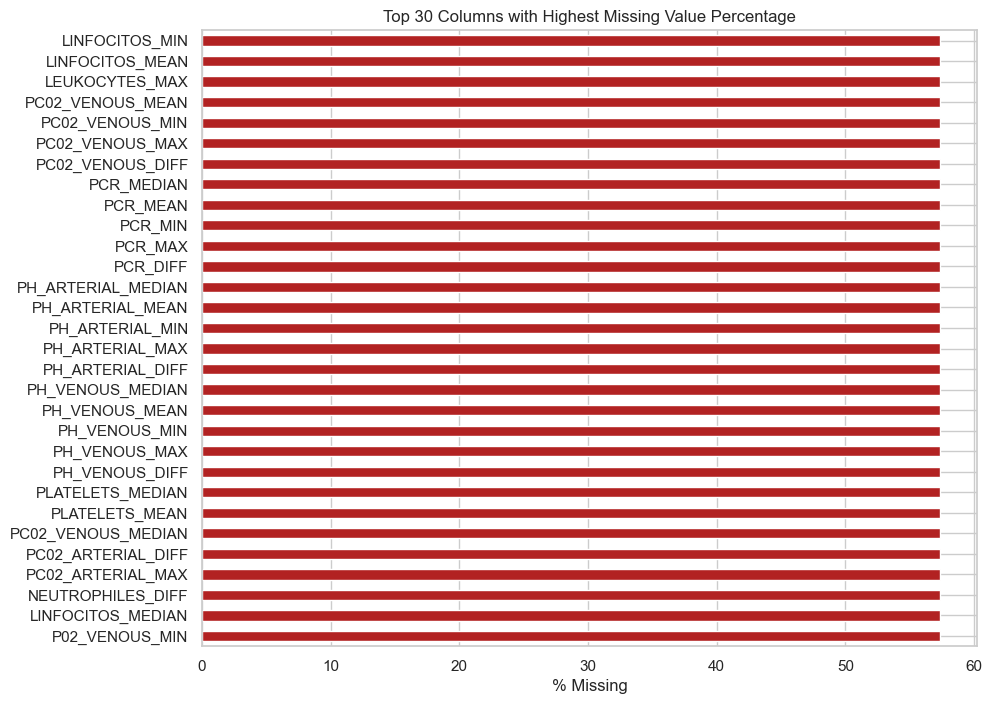

In [4]:
miss = df.isna().mean() * 100
miss_sorted = miss.sort_values(ascending=False)

print(f'Global missing rate: {100 * df.isna().sum().sum() / df.size:.2f}%')
print(f"Columns with > 70% missing: {(miss_sorted > 70).sum()}")

# Plot the top 30 most missing columns
plt.figure(figsize=(10, 8))
miss_sorted.head(30).sort_values().plot(kind='barh', color='firebrick')
plt.title('Top 30 Columns with Highest Missing Value Percentage')
plt.xlabel('% Missing')
plt.show()

## 4. Correlation Subset
Plotting 230 variables is unreadable. We isolate the continuous variables with low missing rates.

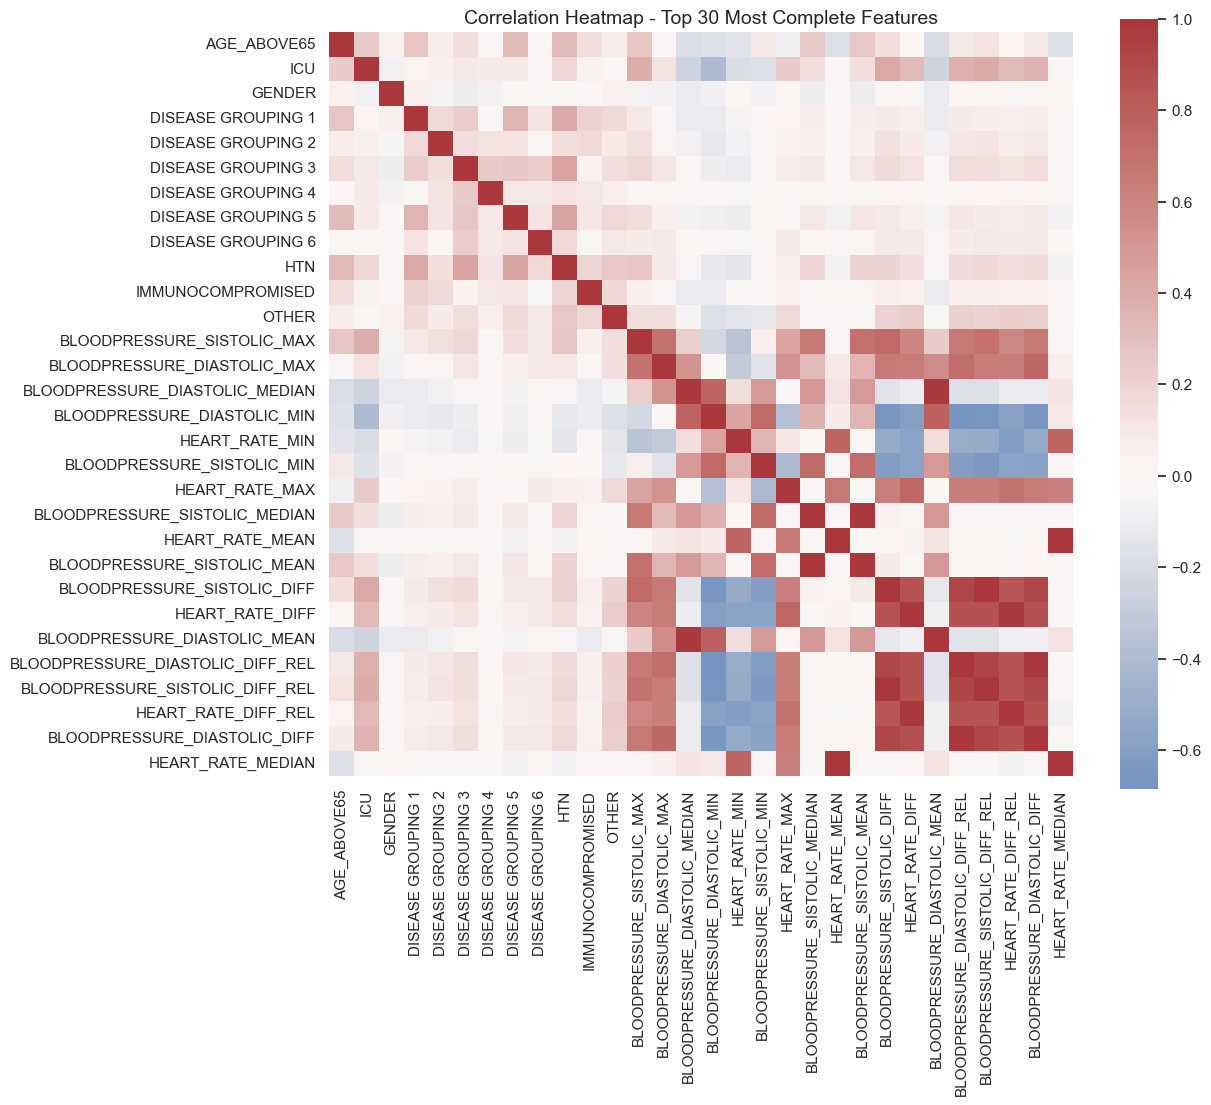

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'PATIENT_VISIT_IDENTIFIER' in num_cols: num_cols.remove('PATIENT_VISIT_IDENTIFIER')

# Take top 30 numeric columns with the least missing data
low_miss_cols = miss[num_cols].sort_values().index[:30]

plt.figure(figsize=(12, 10))
corr = df[low_miss_cols].dropna().corr()
sns.heatmap(corr, cmap='vlag', center=0, square=True)
plt.title('Correlation Heatmap - Top 30 Most Complete Features', fontsize=14)
plt.show()

## 5. Demographic Exploration
Beyond lab tests, demographics are pivotal for ICU clustering. Let's look at Age and Gender distributions.

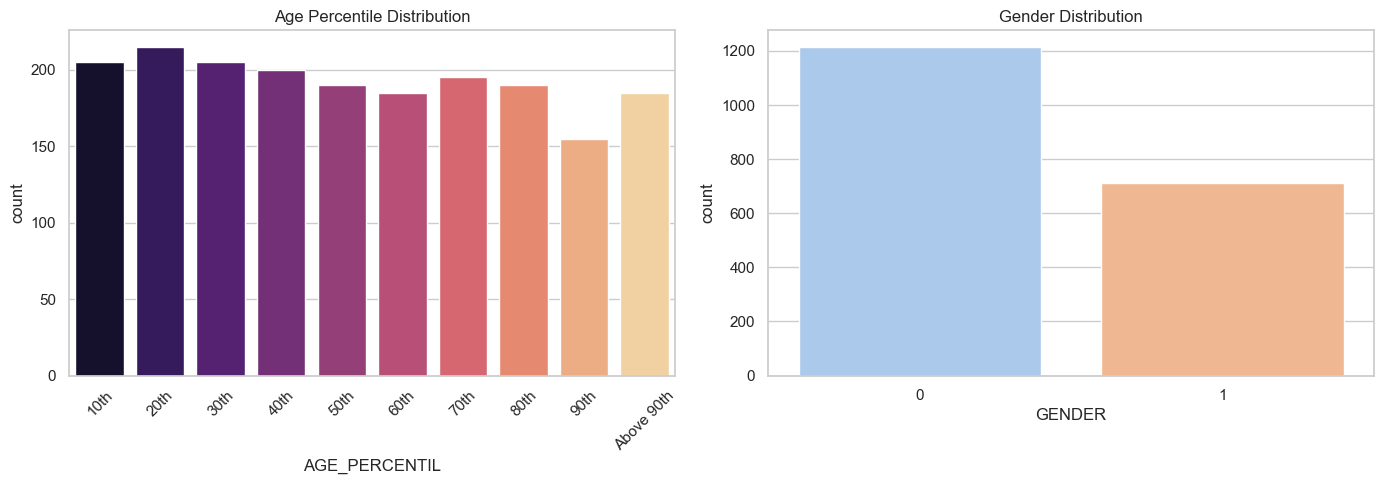

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot for Age Percentile (if present)
if 'AGE_PERCENTIL' in df.columns:
    age_order = sorted([x for x in df['AGE_PERCENTIL'].dropna().unique() if isinstance(x, str)])
    if not age_order: age_order = sorted(df['AGE_PERCENTIL'].dropna().unique())
    sns.countplot(data=df, x='AGE_PERCENTIL', order=age_order, ax=axes[0], palette='magma')
    axes[0].set_title('Age Percentile Distribution')
    axes[0].tick_params(axis='x', rotation=45)

# Countplot for Gender
if 'GENDER' in df.columns:
    sns.countplot(data=df, x='GENDER', ax=axes[1], palette='pastel')
    axes[1].set_title('Gender Distribution')

plt.tight_layout()
plt.show()